In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
load_dotenv()

True

In [4]:
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

d:\Generative_AI\LangGraph\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [6]:
def gen_joke(state: JokeState):
    prompt = f"generate a joke for the topic : {state['topic']}"

    response = model.invoke(prompt).content

    return {'joke' : response}

In [7]:
def exp_joke(state: JokeState):
    prompt = f"explain the below joke \n{state['joke']}"

    response = model.invoke(prompt).content
    
    return {'explanation': response}

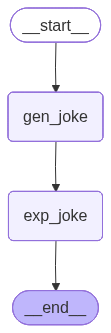

In [9]:
graph = StateGraph(JokeState)

graph.add_node("gen_joke", gen_joke)
graph.add_node("exp_joke", exp_joke)

graph.add_edge(START, "gen_joke")
graph.add_edge("gen_joke", "exp_joke")
graph.add_edge("exp_joke", END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [11]:
config1 = {"configurable" : {"thread_id" : "1"}}
workflow.invoke({"topic" : "snack"}, config= config1)

{'topic': 'snack',
 'joke': 'Why did the snack go to therapy? \n\nBecause it was feeling crumby.',
 'explanation': 'The joke is a play on words. It\'s a pun.\n\n"Feeling crumby" has a double meaning here. \n\n1. "Crumby" is an adjective that means feeling unwell or in a bad mood.\n2. "Crumby" can also refer to the state of being crushed or broken into small pieces, like when a snack becomes stale or crumbles.\n\nIn this joke, the punchline "feeling crumby" is used to make a wordplay on the snack aspect of the setup. The joke relies on the listener understanding both meanings of "crumby" to appreciate the pun.'}

In [12]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'snack', 'joke': 'Why did the snack go to therapy? \n\nBecause it was feeling crumby.', 'explanation': 'The joke is a play on words. It\'s a pun.\n\n"Feeling crumby" has a double meaning here. \n\n1. "Crumby" is an adjective that means feeling unwell or in a bad mood.\n2. "Crumby" can also refer to the state of being crushed or broken into small pieces, like when a snack becomes stale or crumbles.\n\nIn this joke, the punchline "feeling crumby" is used to make a wordplay on the snack aspect of the setup. The joke relies on the listener understanding both meanings of "crumby" to appreciate the pun.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f177bbc-5b8f-6915-8002-b0b39116c41f'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-04T15:19:38.501023+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f177bbc-4d07-6172-8001-3ea364c1b85c'}

In [14]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'snack', 'joke': 'Why did the snack go to therapy? \n\nBecause it was feeling crumby.', 'explanation': 'The joke is a play on words. It\'s a pun.\n\n"Feeling crumby" has a double meaning here. \n\n1. "Crumby" is an adjective that means feeling unwell or in a bad mood.\n2. "Crumby" can also refer to the state of being crushed or broken into small pieces, like when a snack becomes stale or crumbles.\n\nIn this joke, the punchline "feeling crumby" is used to make a wordplay on the snack aspect of the setup. The joke relies on the listener understanding both meanings of "crumby" to appreciate the pun.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f177bbc-5b8f-6915-8002-b0b39116c41f'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-04T15:19:38.501023+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f177bbc-4d07-6172-8001-3ea364c1b85c'

In [15]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({"topic" : "fasting"}, config=config2)

{'topic': 'fasting',
 'joke': 'Why did the person bring a ladder to their fasting session?\n\nBecause they wanted to take their abstinence to a higher level.',
 'explanation': 'This is a play on words. The joke is about a person fasting, which means giving up eating or drinking for a period of time. In this case, the person is trying to take their abstinence (giving something up) to a different level.\n\nHowever, "to a higher level" has a double meaning here. A ladder is a physical object used to climb to higher places, so the person is literally bringing a ladder to their fasting session. But "to a higher level" can also be a common idiomatic expression meaning to a greater or more profound degree.\n\nThe punchline is a pun, as it\'s a clever connection between the literal meaning of having a ladder and the idiomatic expression of taking something to a higher level. The joke relies on this wordplay to create humor.'}

In [16]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'fasting', 'joke': 'Why did the person bring a ladder to their fasting session?\n\nBecause they wanted to take their abstinence to a higher level.', 'explanation': 'This is a play on words. The joke is about a person fasting, which means giving up eating or drinking for a period of time. In this case, the person is trying to take their abstinence (giving something up) to a different level.\n\nHowever, "to a higher level" has a double meaning here. A ladder is a physical object used to climb to higher places, so the person is literally bringing a ladder to their fasting session. But "to a higher level" can also be a common idiomatic expression meaning to a greater or more profound degree.\n\nThe punchline is a pun, as it\'s a clever connection between the literal meaning of having a ladder and the idiomatic expression of taking something to a higher level. The joke relies on this wordplay to create humor.'}, next=(), config={'configurable': {'thread_id': '

In [18]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'fasting', 'joke': 'Why did the person bring a ladder to their fasting session?\n\nBecause they wanted to take their abstinence to a higher level.', 'explanation': 'This is a play on words. The joke is about a person fasting, which means giving up eating or drinking for a period of time. In this case, the person is trying to take their abstinence (giving something up) to a different level.\n\nHowever, "to a higher level" has a double meaning here. A ladder is a physical object used to climb to higher places, so the person is literally bringing a ladder to their fasting session. But "to a higher level" can also be a common idiomatic expression meaning to a greater or more profound degree.\n\nThe punchline is a pun, as it\'s a clever connection between the literal meaning of having a ladder and the idiomatic expression of taking something to a higher level. The joke relies on this wordplay to create humor.'}, next=(), config={'configurable': {'thread_id': 